In [ ]:
from nf_functions import *
import sympy as sp
import numpy as np
import copy
import scipy.stats as scp
import math
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 35,           # Dimensione generale del font
    'axes.titlesize': 35,      # Titolo dell'asse
    'axes.labelsize': 35,      # Etichette degli assi
    'legend.fontsize': 30,     # Legenda
    'xtick.labelsize': 35,     # Etichette asse x
    'ytick.labelsize': 35      # Etichette asse y
})

plt.rcParams['text.latex.preamble']=r"\usepackage{lmodern}"
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 30
plt.rcParams['font.family'] = 'lmodern'

In [ ]:
N_PC_values = [10]
sigma = sp.Rational(7, 5)
number_of_samples = 100
Bif_values = ["Transcritical","S","Pitchfork"]
mu_values = [[0,sigma,1],[0,sigma],[0,sigma,1]]
Bif_values = ["Saddle"]
mu_values = [[sp.Rational(1,1)]]
sigma = sp.Rational(1, 5)

for i, Bif in enumerate(Bif_values):
    for mu in mu_values[i]:
        for N_PC in N_PC_values:

            F, Variables = Build_system(N_PC, Bif)
            G = Build_system_forcing(F, mu, sigma, Variables, Bif)
            solutions = Numerical_system_solver(G, Variables, 100)
            print(solutions)
            residuals = [0 for _ in range(len(solutions))]
            polynomials = Calculate_polynomials(N_PC, mu, sigma, solutions, residuals)
            Plot_polynomials(polynomials,N_PC,mu,sigma,Bif,save=True)
            number_polynomials = len(polynomials)
            # sampling_peaks = Sampling_histogram(N_PC, mu, sigma, polynomials, number_of_samples, Bif, graph=True)
            # extrema_peaks = Extrema_histogram(N_PC, mu, sigma, solutions, polynomials, Bif, graph=True)
                        
            print(f"Degree: {N_PC}")
            print(f"Accepted polynomials: {number_polynomials}")


            # --- Analisi simbolica con i polinomi di Legendre ---

            # Variabile simbolica
            x = sp.Symbol('x')

            def symbolic_legendre_function(coeffs, mu, sigma):
                """Costruisce simbolicamente u(x) = sum_i c_i P_i((x-mu)/sigma)"""
                z = (x - mu) / sigma
                u_expr = sum(c * sp.legendre(i, z) for i, c in enumerate(coeffs))
                return sp.simplify(u_expr)

            # --- Estrazione dei coefficienti ---
            # Adatta qui in base alla struttura di 'new_polynomials' o 'polynomials'
            # Ad esempio, se new_polynomials è una lista di coefficienti [c0, c1, c2, ...]:
            for k in range (len(polynomials)):
                coeffs = [sp.Rational(c) for c in polynomials[k]]
                print(f"\nPOLINOMIO {k+1}")
                Plot_polynomials([polynomials[k]],N_PC,mu,sigma,Bif,save=True)


                # Costruisci la funzione simbolica u(x)
                u = symbolic_legendre_function(coeffs, mu, sigma)
                # Eleva al quadrato
                u_sq = sp.expand(u**2)

                # Calcola l'integrale su (mu - sigma, mu + sigma)
                # for l in range(2*N_PC+1):
                #     integral_expr = sp.integrate((u_sq-x)*(x**l), (x, mu - sigma, mu + sigma))
                #     integral_simplified = sp.simplify(integral_expr)

                #     # Stampa il valore simbolico e numerico
                #     print(f"Integrale di (u(x)^2-x)*x^{l} su (mu - sigma, mu + sigma): ")
                #     print(float(integral_simplified))
                # --- Integrazione contro i polinomi di Legendre ---
                residual=0
                for l in range(2 * N_PC + 1):
                    # Definisci il polinomio di Legendre P_l in termini di z = (x - mu)/sigma
                    z = (x - mu) / sigma
                    P_l = sp.legendre(l, z)

                    # Calcola l'integrale di (u(x)^2 - x)*P_l((x-mu)/sigma)
                    integral_expr = sp.integrate((u_sq - x) * P_l, (x, mu - sigma, mu + sigma))

                    # Normalizzazione (se vuoi i coefficienti ortonormali su [-1,1])
                    # I polinomi di Legendre soddisfano ∫_{-1}^{1} P_m P_n = 2/(2n+1) δ_mn
                    # quindi qui possiamo moltiplicare per un fattore di scala sigma, perché l'intervallo è scalato
                    normalization = sigma * 2 / (2 * l + 1)
                    projection_coeff = integral_expr / normalization
                    residual+=abs(float(projection_coeff))
                    # --- Stampa risultati ---
                    # print(f"Integrale di (f(u,mu))*P_{l}: {float(integral_expr)}")
                    # print(f"Integrale di (f(u,mu))*P_{l} normalizzato: {float(projection_coeff)}")
                
                print(f"Norma del residuo: {residual}")
                u_sq_minus_mu = sp.simplify(u_sq)
                # Converti in funzione numerica per il plotting
                u_sq_minus_mu_func = sp.lambdify(x, u_sq_minus_mu, "numpy")
                u_func = sp.lambdify(x, u, "numpy")

                # Dominio di plot: [mu - sigma, mu + sigma]
                x_vals = np.linspace(float(mu - sigma), float(mu + sigma), 400)
                u_sq_minus_mu_vals = u_sq_minus_mu_func(x_vals)

                plt.figure(figsize=(7, 5))
                plt.plot(x_vals, u_sq_minus_mu_vals)
                plt.plot(x_vals, x_vals, linestyle="--")

                plt.grid(alpha=0.3)
                plt.show()


In [ ]:
# ============================================================
# Imports
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import legval, leggauss, Legendre

# ============================================================
# FAST RESIDUAL COMPUTATION
# ============================================================
def compute_legendre_residual(coeffs, mu, sigma, N_PC, quad_order=80):
    z, w = leggauss(quad_order)

    u_vals = legval(z, coeffs)
    x_vals = mu + sigma * z

    f_vals = u_vals**2 - x_vals

    residual = 0.0
    for l in range(2 * N_PC + 1):
        P_l = legval(z, [0]*l + [1])
        residual += (np.sum(w * f_vals * P_l))**2

    return np.sqrt(residual)


# ============================================================
# PLOTTING
# ============================================================
def plot_solution(coeffs, mu, sigma, title=""):
    z = np.linspace(-1, 1, 400)
    u_vals = legval(z, coeffs)
    x_vals = mu + sigma * z

    plt.figure(figsize=(7,5))
    plt.plot(x_vals, u_vals**2, label=r"$u(x)^2$")
    plt.plot(x_vals, x_vals, "--", label=r"$x$")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.title(title)
    plt.show()


# ============================================================
# MAIN SCRIPT
# ============================================================
N_PC_values = [20]

Bif_values = ["Saddle"]
mu_values = [[4.0]]
sigma = 2.0

for i, Bif in enumerate(Bif_values):
    for mu in mu_values[i]:
        for N_PC in N_PC_values:

            # ---- Build and solve system (UNCHANGED) ----
            F, Variables = Build_system(N_PC, Bif)
            G = Build_system_forcing(F, mu, sigma, Variables, Bif)
            solutions = Numerical_system_solver(G, Variables, 100)

            residuals = [0.0 for _ in range(len(solutions))]
            polynomials = Calculate_polynomials(
                N_PC, mu, sigma, solutions, residuals
            )

            Plot_polynomials(polynomials, N_PC, mu, sigma, Bif, save=True)

            print(f"\nDegree: {N_PC}")
            print(f"Accepted polynomials: {len(polynomials)}")

            # ---- CORRECT + FAST ANALYSIS ----
            for k, poly in enumerate(polynomials):

                # ✅ THIS IS THE KEY LINE
                if isinstance(poly, Legendre):
                    coeffs = poly.coef
                else:
                    raise TypeError(
                        f"Expected numpy.polynomial.Legendre, got {type(poly)}"
                    )

                residual = compute_legendre_residual(
                    coeffs, mu, sigma, N_PC
                )

                print(f"\nPolynomial {k+1}")
                print(f"Residual norm: {residual:.3e}")

                plot_solution(
                    coeffs, mu, sigma,
                    title=f"{Bif},  N={N_PC}, solution {k+1}"
                )


## Min-Max residuals

In [14]:
# ============================================================
# MAIN SCRIPT
# ============================================================
N_PC_values = [N for N in range (1,31)]

Bif_values = ["Saddle"]
mu_values = [[1.0]]
sigma = 0.2

# Storage for final results
results = []

for i, Bif in enumerate(Bif_values):
    for mu in mu_values[i]:
        for N_PC in N_PC_values:

            # ---- Build and solve system (UNCHANGED) ----
            F, Variables = Build_system(N_PC, Bif)
            G = Build_system_forcing(F, mu, sigma, Variables, Bif)
            solutions = Numerical_system_solver(G, Variables, 1000)

            residuals = [0.0 for _ in range(len(solutions))]
            polynomials = Calculate_polynomials(
                N_PC, mu, sigma, solutions, residuals
            )

            # ---- Compute residual statistics ----
            res_vals = []
            kept = 0
            discarded = 0

            for poly in polynomials:
                if not isinstance(poly, Legendre):
                    raise TypeError(
                        f"Expected numpy.polynomial.Legendre, got {type(poly)}"
                    )

                coeffs = poly.coef

                # 🔹 FILTER: energy-based
                total_energy = np.sum(coeffs**2)
                high_energy = np.sum(coeffs[2:]**2)
                if total_energy == 0 or (high_energy / total_energy) < 1e-3:
                    discarded += 1
                    continue

                kept += 1

                res = compute_legendre_residual(
                    coeffs, mu, sigma, N_PC
                )
                res_vals.append(res)

            # ---- Summary per N_PC ----
            if res_vals:
                min_res = np.min(res_vals)
                max_res = np.max(res_vals)
            else:
                min_res = np.nan
                max_res = np.nan

            results.append({
                "Bif": Bif,
                "mu": mu,
                "sigma": sigma,
                "N_PC": N_PC,
                "n_solutions": len(res_vals),
                "min_residual": min_res,
                "max_residual": max_res
            })

            # ---- Print summary for this N_PC ----
            print(
                f"N_PC = {N_PC:2d} | "
                f"kept = {kept:3d} | "
                f"discarded = {discarded:3d} | "
                f"min res = {min_res:.3e} | "
                f"max res = {max_res:.3e}"
            )

# ============================================================
# Print final summary: min/max residual vs N_PC
# ============================================================
print("\n=== Residuals vs N_PC ===")
for res in results:
    print(
        f"N_PC = {res['N_PC']:2d} | "
        f"min residual = {res['min_residual']:.3e} | "
        f"max residual = {res['max_residual']:.3e}"
    )

# ============================================================
# OPTIONAL: save results to file
# ============================================================
import csv

with open("residual_summary.csv", "w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=results[0].keys()
    )
    writer.writeheader()
    writer.writerows(results)


Solving:   4%|▎         | 36/1000 [00:00<00:00, 5407.74it/s]

N_PC =  1 | kept =   0 | discarded =   4 | min res = nan | max res = nan


Solving:   4%|▍         | 43/1000 [00:00<00:01, 864.68it/s]


N_PC =  2 | kept =   6 | discarded =   2 | min res = 4.756e-01 | max res = 5.645e-01


Solving:  10%|▉         | 98/1000 [00:00<00:00, 2512.73it/s]


...

N_PC = 28 | kept = 727 | discarded =   2 | min res = 1.655e-02 | max res = 1.624e-01


Solving: 100%|██████████| 1000/1000 [02:26<00:00,  6.82it/s]


N_PC = 29 | kept = 755 | discarded =   2 | min res = 1.572e-02 | max res = 1.584e-01


Solving: 100%|██████████| 1000/1000 [02:52<00:00,  5.79it/s]


N_PC = 30 | kept = 735 | discarded =   2 | min res = 1.497e-02 | max res = 1.514e-01

=== Residuals vs N_PC ===
N_PC =  1 | min residual = nan | max residual = nan
N_PC =  2 | min residual = 4.756e-01 | max residual = 5.645e-01
N_PC =  3 | min residual = 3.227e-01 | max residual = 5.210e-01
N_PC =  4 | min residual = 2.317e-01 | max residual = 4.415e-01
N_PC =  5 | min residual = 1.775e-01 | max residual = 4.100e-01
N_PC =  6 | min residual = 1.407e-01 | max residual = 3.691e-01
N_PC =  7 | min residual = 1.153e-01 | max residual = 3.525e-01
N_PC =  8 | min residual = 9.649e-02 | max residual = 3.268e-01
N_PC =  9 | min residual = 8.239e-02 | max residual = 2.970e-01
N_PC = 10 | min residual = 7.134e-02 | max residual = 2.853e-01
N_PC = 11 | min residual = 6.259e-02 | max residual = 2.789e-01
N_PC = 12 | min residual = 5.546e-02 | max residual = 2.607e-01
N_PC = 13 | min residual = 4.960e-02 | max residual = 2.569e-01
N_PC = 14 | min residual = 4.469e-02 | max residual = 2.414e-01
N_PC

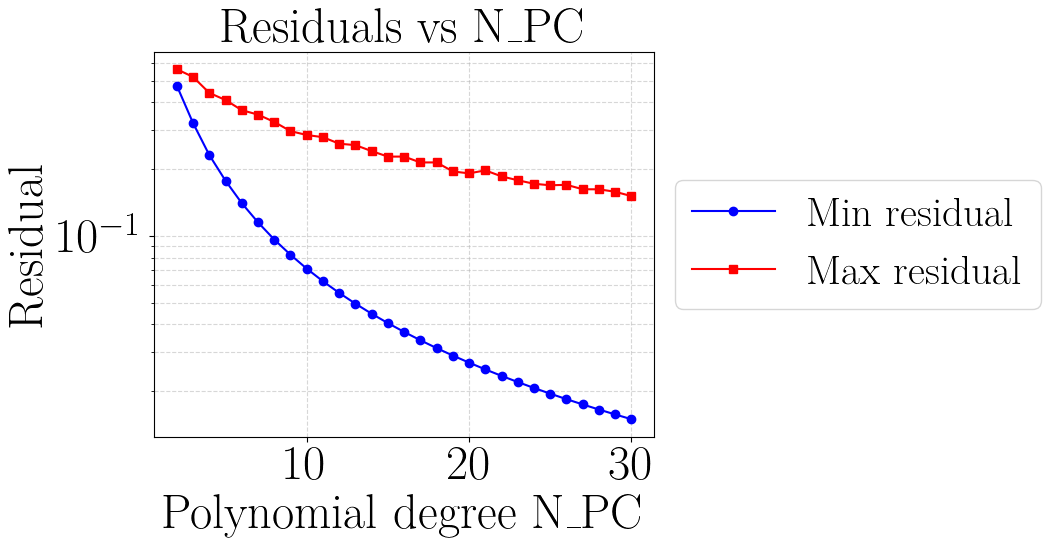

In [18]:
import matplotlib.pyplot as plt

# Extract N_PC, min, and max residuals for plotting
N_list = [res['N_PC'] for res in results]
min_res_list = [res['min_residual'] for res in results]
max_res_list = [res['max_residual'] for res in results]

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(N_list, min_res_list, 'o-', label='Min residual', color='blue')
ax.plot(N_list, max_res_list, 's-', label='Max residual', color='red')

ax.set_xlabel("Polynomial degree N_PC")
ax.set_ylabel("Residual")
ax.set_yscale("log")
ax.set_title("Residuals vs N_PC")
ax.grid(True, which="both", ls="--", alpha=0.5)

# Place legend outside the plot
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Adjust figure width if needed (optional)
plt.subplots_adjust(right=0.75)

# Save the plot as a PNG file
plt.savefig("residuals_vs_NPC.png", dpi=300, bbox_inches='tight')

# Optional: display it
# plt.show()
